<a href="https://colab.research.google.com/github/Vilasith-c/Case-Study-ML-Cyder-Crime/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install if needed:
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


(125973, 42) (22544, 42)
Combined: (148517, 42)
Missing values after cleaning: 0
Final feature shape: (148517, 122)
Classes: ['DoS' 'Normal' 'Other' 'Probe' 'R2L' 'U2R']


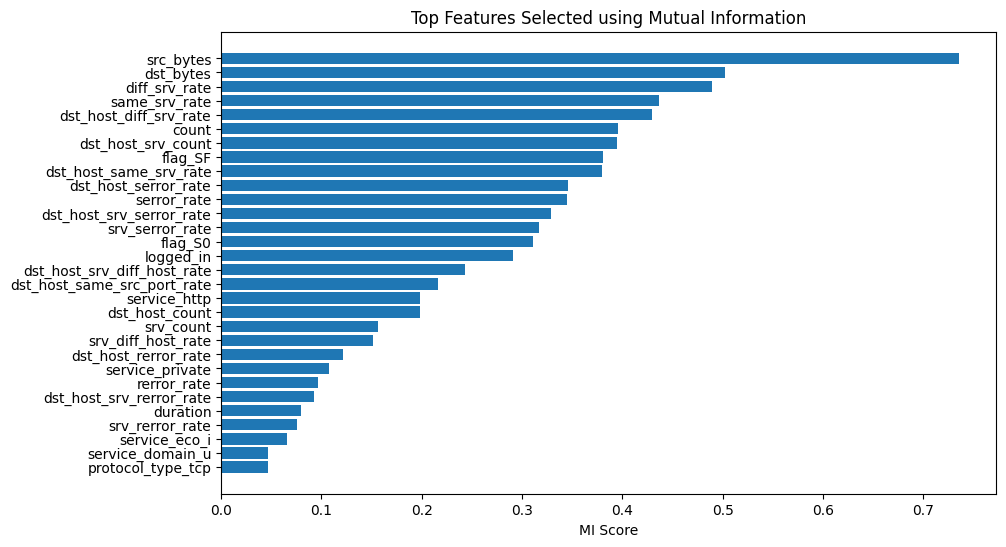

              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     16016
      Normal       0.99      1.00      1.00     23117
       Other       0.00      0.00      0.00         9
       Probe       0.99      0.99      0.99      4223
         R2L       0.96      0.93      0.95      1160
         U2R       0.69      0.29      0.41        31

    accuracy                           0.99     44556
   macro avg       0.77      0.70      0.72     44556
weighted avg       0.99      0.99      0.99     44556



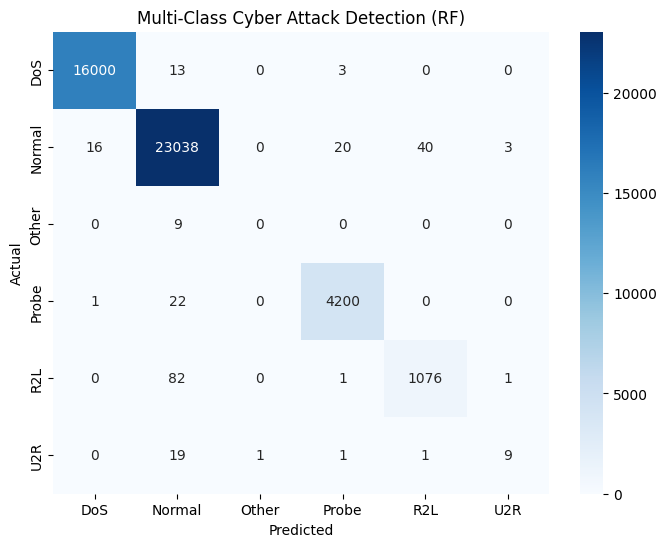

Accuracy: 0.9948
Precision: 0.9944
Recall: 0.9948
F1-score: 0.9945


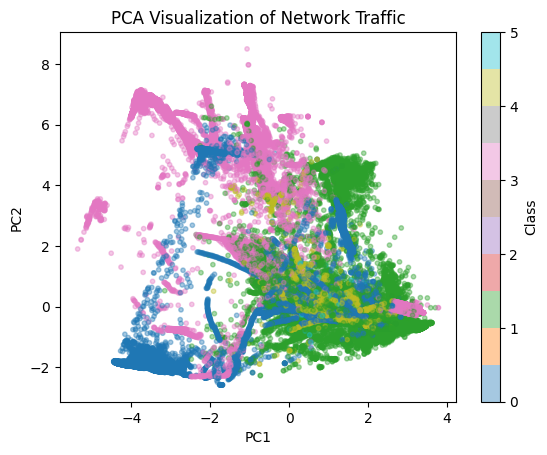

Silhouette Score: 0.47557187676742524
Davies-Bouldin Index: 1.490496460672984


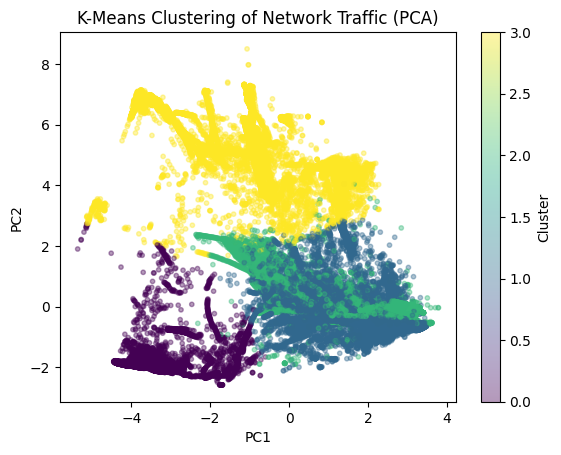

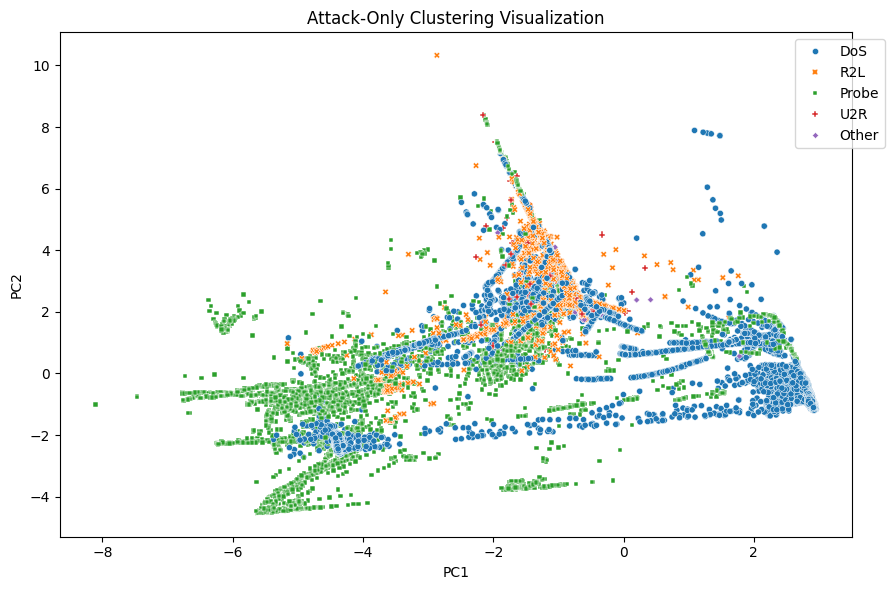

In [ ]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# =========================================
# 2. LOAD NSL-KDD DATA
# =========================================
train = pd.read_csv("/content/NSL_KDD_Train.csv", header=None, low_memory=False)
test  = pd.read_csv("/content/NSL_KDD_Test.csv", header=None, low_memory=False)

print(train.shape, test.shape)
# =========================================
# 3. ADD COLUMN NAMES
# =========================================
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes',
'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
'is_host_login','is_guest_login','count','srv_count','serror_rate',
'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
'diff_srv_rate','srv_diff_host_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','label'
]

train.columns = columns
test.columns = columns

full = pd.concat([train, test], ignore_index=True)
full['su_attempted'] = full['su_attempted'].replace(2, 1)

print("Combined:", full.shape)

# =========================================
# 4. HANDLE MISSING VALUES
# =========================================
full.replace(['?', '', ' '], np.nan, inplace=True)

X = full.drop('label', axis=1)
y = full['label']

cat_cols = ['protocol_type', 'service', 'flag']
num_cols = [c for c in X.columns if c not in cat_cols]

for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])

print("Missing values after cleaning:", X.isnull().sum().sum())

# =========================================
# 5. ENCODING + SCALING
# =========================================
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(X[cat_cols])

scaler = StandardScaler()
X_num = scaler.fit_transform(X[num_cols])

X_processed = np.hstack((X_num, X_cat))

num_feature_names = list(num_cols)
cat_feature_names = encoder.get_feature_names_out(cat_cols).tolist()
feature_names = num_feature_names + cat_feature_names

print("Final feature shape:", X_processed.shape)

# =========================================
# 6. MULTI-CLASS LABEL MAPPING
# =========================================
attack_map = {
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','mailbomb':'DoS','apache2':'DoS','processtable':'DoS','udpstorm':'DoS',
    'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','mscan':'Probe','saint':'Probe',
    'guess_passwd':'R2L','ftp_write':'R2L','imap':'R2L','phf':'R2L','multihop':'R2L',
    'warezmaster':'R2L','warezclient':'R2L','spy':'R2L','snmpguess':'R2L','snmpgetattack':'R2L',
    'httptunnel':'R2L','sendmail':'R2L','named':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','rootkit':'U2R','perl':'U2R','sqlattack':'U2R','xterm':'U2R',
    'normal':'Normal'
}

y_multi = y.map(attack_map).fillna('Other')

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_multi)

print("Classes:", label_encoder.classes_)

# =========================================
# 7. EXTERNAL FEATURE SELECTION (MUTUAL INFORMATION)
# =========================================
mi_scores = mutual_info_classif(X_processed, y_encoded, random_state=42)

mi_df = pd.DataFrame({
    "Feature": feature_names,
    "MI_Score": mi_scores
}).sort_values("MI_Score", ascending=False)

TOP_K = 30
top_features = mi_df.head(TOP_K)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["MI_Score"])
plt.gca().invert_yaxis()
plt.title("Top Features Selected using Mutual Information")
plt.xlabel("MI Score")
plt.show()

selected_indices = [feature_names.index(f) for f in top_features["Feature"]]
X_selected = X_processed[:, selected_indices]

# =========================================
# 8. TRAIN–TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

# =========================================
# 9. RANDOM FOREST CLASSIFIER
# =========================================
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# =========================================
# 10. MODEL EVALUATION
# =========================================
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Multi-Class Cyber Attack Detection (RF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='weighted'
)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# =========================================
# 11. PCA VISUALIZATION
# =========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_encoded, cmap='tab10', s=10, alpha=0.4)
plt.title("PCA Visualization of Network Traffic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Class")
plt.show()

# =========================================
# 12. K-MEANS CLUSTERING
# =========================================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_selected)

print("Silhouette Score:", silhouette_score(X_selected, cluster_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X_selected, cluster_labels))

plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='viridis', s=10, alpha=0.4)
plt.title("K-Means Clustering of Network Traffic (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()

# =========================================
# CLUSTER → ATTACK NAME MAPPING
# =========================================
attack_idx = y_multi != "Normal"

X_attack = X_processed[attack_idx]
y_attack = y_multi[attack_idx]

pca_attack = PCA(n_components=2)
X_attack_pca = pca_attack.fit_transform(X_attack)

kmeans_attack = KMeans(n_clusters=4, random_state=42, n_init=10)
attack_clusters = kmeans_attack.fit_predict(X_attack)

plt.figure(figsize=(9,6))
sns.scatterplot(
    x=X_attack_pca[:,0],
    y=X_attack_pca[:,1],
    hue=y_attack,
    style=y_attack,
    palette="tab10",
    s=20
)

plt.title("Attack-Only Clustering Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()



(125973, 42) (22544, 42)
Combined: (148517, 42)
Missing values after cleaning: 0
Final feature shape: (148517, 122)
Classes: ['DoS' 'Normal' 'Other' 'Probe' 'R2L' 'U2R']
========== XGBOOST PERFORMANCE ==========
Accuracy  : 0.9961
Precision : 0.9959
Recall    : 0.9961
F1-score  : 0.9960


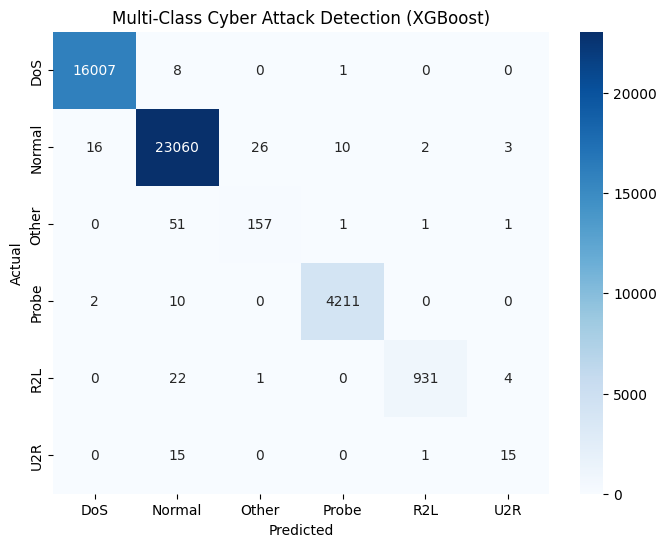

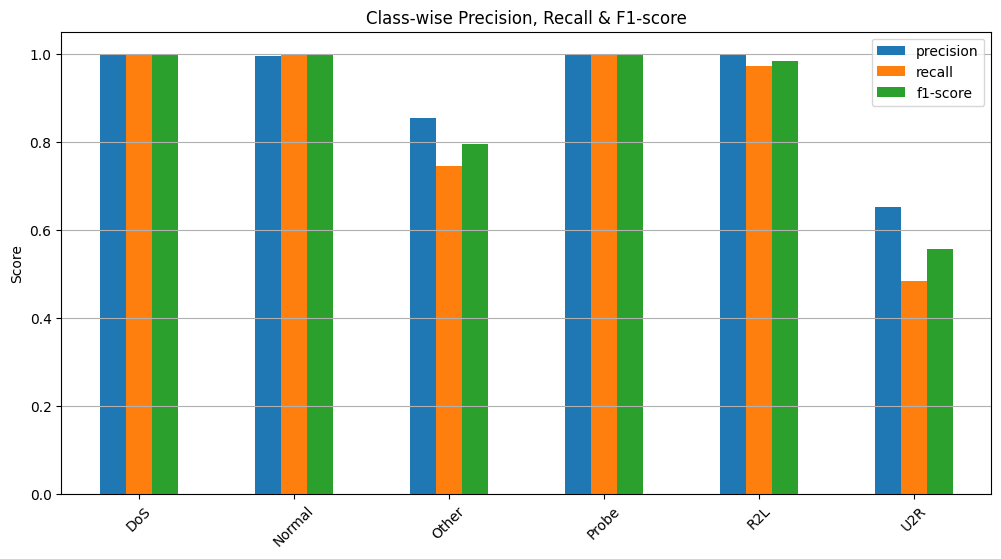

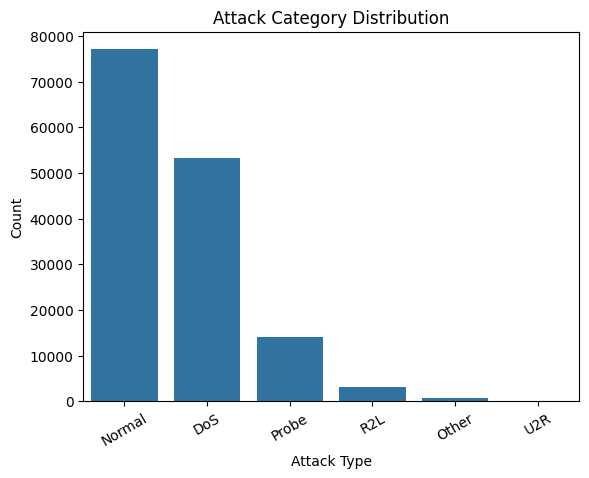

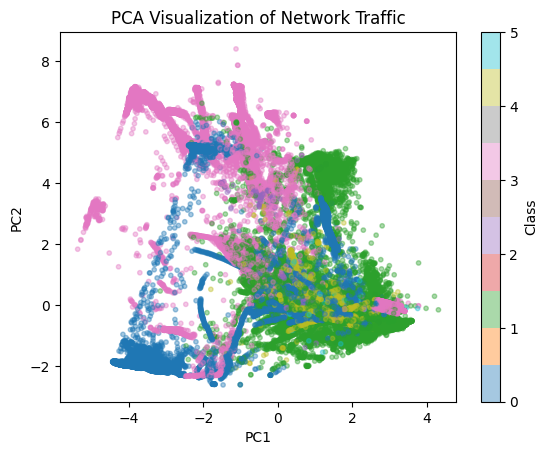

Silhouette Score: 0.41711681107186616
Davies-Bouldin Index: 0.9835937883931718


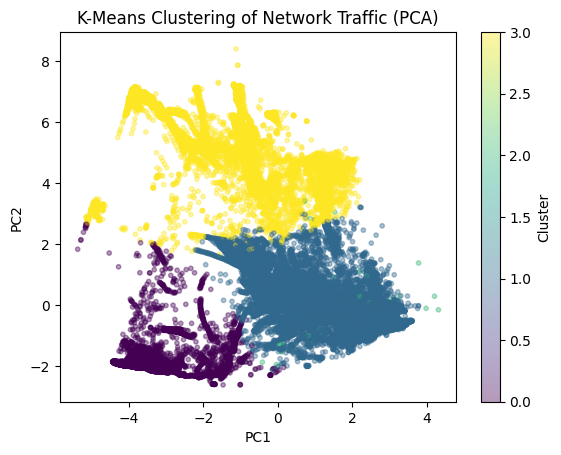

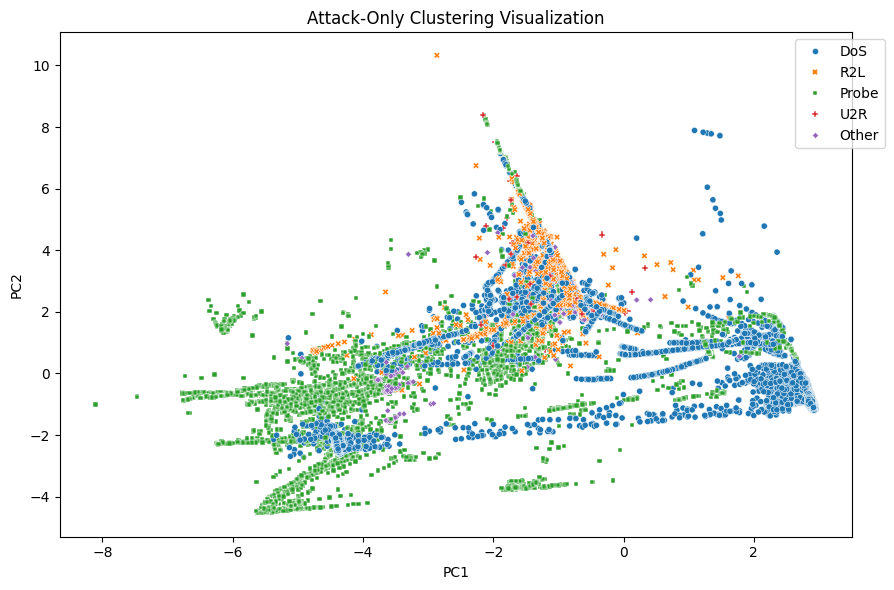

In [ ]:
# =========================================
# 1. IMPORT LIBRARIES (XGBOOST + KMEANS)
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

from xgboost import XGBClassifier

# =========================================
# 2. LOAD NSL-KDD DATA
# =========================================
train = pd.read_csv("/content/NSL_KDD_Train.csv", header=None)
test  = pd.read_csv("/content/NSL_KDD_Test.csv", header=None)

print(train.shape, test.shape)

# =========================================
# 3. ADD COLUMN NAMES
# =========================================
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes',
'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
'is_host_login','is_guest_login','count','srv_count','serror_rate',
'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
'diff_srv_rate','srv_diff_host_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','label'
]

train.columns = columns
test.columns = columns

full = pd.concat([train, test], ignore_index=True)
full['su_attempted'] = full['su_attempted'].replace(2, 1)

print("Combined:", full.shape)

# =========================================
# 4. HANDLE MISSING VALUES
# =========================================
full.replace(['?', '', ' '], np.nan, inplace=True)

X = full.drop('label', axis=1)
y = full['label']

cat_cols = ['protocol_type', 'service', 'flag']
num_cols = [c for c in X.columns if c not in cat_cols]

for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])

print("Missing values after cleaning:", X.isnull().sum().sum())

# =========================================
# 5. ENCODING + SCALING
# =========================================
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(X[cat_cols])

scaler = StandardScaler()
X_num = scaler.fit_transform(X[num_cols])

X_processed = np.hstack((X_num, X_cat))

# Feature names (important for viva)
num_features = num_cols
cat_features = encoder.get_feature_names_out(cat_cols).tolist()
feature_names = num_features + cat_features

print("Final feature shape:", X_processed.shape)

# =========================================
# 6. MULTI-CLASS ATTACK MAPPING (FIXED)
# =========================================
attack_map = {
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','mailbomb':'DoS','apache2':'DoS','processtable':'DoS','udpstorm':'DoS',
    'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','mscan':'Probe','saint':'Probe',
    'guess_passwd':'R2L','ftp_write':'R2L','imap':'R2L','phf':'R2L','multihop':'R2L',
    'warezmaster':'R2L','warezclient':'R2L','spy':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','rootkit':'U2R',
    'perl':'U2R','sqlattack':'U2R','xterm':'U2R',
    'normal':'Normal'
}

y_multi = y.map(attack_map).fillna('Other')

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_multi)

print("Classes:", label_encoder.classes_)

# =========================================
# 7. TRAIN–TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

# =========================================
# 8. XGBOOST MODEL (SUPERVISED)
# =========================================
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

# =========================================
# 9. MODEL PERFORMANCE
# =========================================
acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='weighted'
)

print("========== XGBOOST PERFORMANCE ==========")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

# =========================================
# 10. CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Multi-Class Cyber Attack Detection (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================
# 11. CLASS-WISE METRICS BAR PLOT
# =========================================
report = classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report).transpose()

df_report[['precision','recall','f1-score']].iloc[:-3].plot(
    kind='bar', figsize=(12,6)
)
plt.title("Class-wise Precision, Recall & F1-score")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# =========================================
# 12. ATTACK DISTRIBUTION
# =========================================
sns.countplot(x=y_multi, order=y_multi.value_counts().index)
plt.title("Attack Category Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

# =========================================
# 13. PCA VISUALIZATION
# =========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_encoded,
            cmap='tab10', s=10, alpha=0.4)
plt.title("PCA Visualization of Network Traffic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Class")
plt.show()

# =========================================
# 14. K-MEANS CLUSTERING
# =========================================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_processed)

print("Silhouette Score:", silhouette_score(X_processed, cluster_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X_processed, cluster_labels))

# =========================================
# 15. K-MEANS PCA VISUALIZATION
# =========================================
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=cluster_labels,
            cmap='viridis',
            s=10,
            alpha=0.4)

plt.title("K-Means Clustering of Network Traffic (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()

attack_idx = y_multi != "Normal"

X_attack = X_processed[attack_idx]
y_attack = y_multi[attack_idx]

pca_attack = PCA(n_components=2)
X_attack_pca = pca_attack.fit_transform(X_attack)

kmeans_attack = KMeans(n_clusters=4, random_state=42, n_init=10)
attack_clusters = kmeans_attack.fit_predict(X_attack)

plt.figure(figsize=(9,6))
sns.scatterplot(
    x=X_attack_pca[:,0],
    y=X_attack_pca[:,1],
    hue=y_attack,
    style=y_attack,
    palette="tab10",
    s=20
)

plt.title("Attack-Only Clustering Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

